In [2]:
import pandas as pd

In [3]:

df = pd.read_csv('Data/florida_delays_weather_data.csv')

# Check how many missing values are in each column
missing_values = df.isnull().sum()
print(" Missing values per column:\n")
print(missing_values)

#  Show only rows that contain at least one missing value
rows_with_missing = df[df.isnull().any(axis=1)]
print("\n Rows with missing data:\n")
print(rows_with_missing)

FileNotFoundError: [Errno 2] No such file or directory: 'Data/florida_delays_weather_data.csv'

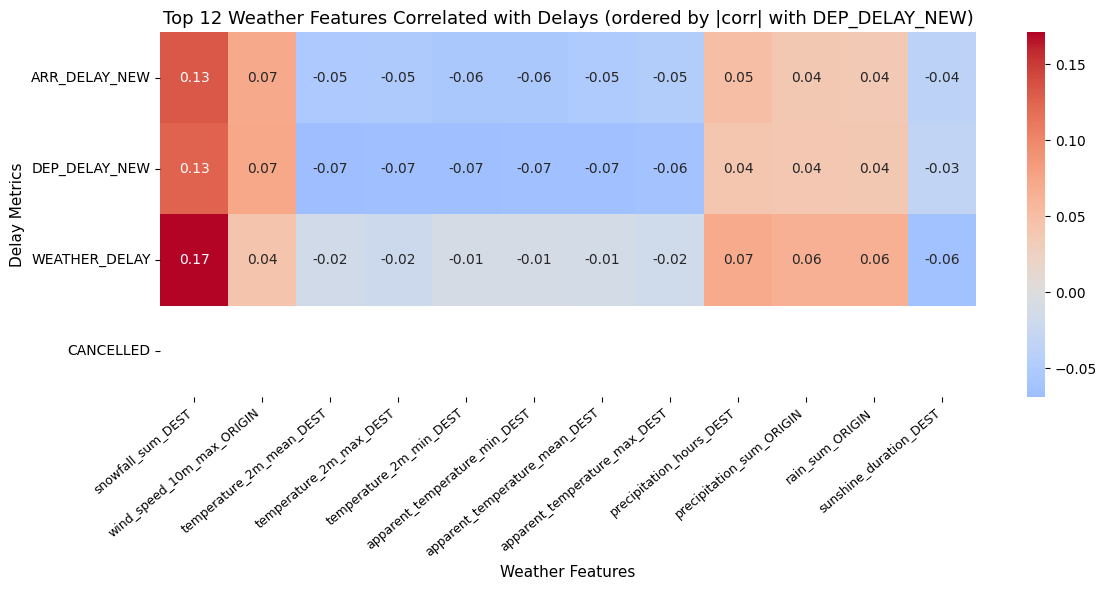

In [6]:
# Load dataset
df = pd.read_csv("florida_delays_weather_data.csv", low_memory=False)

# Delay and weather columns
delay_vars = ["ARR_DELAY_NEW", "DEP_DELAY_NEW", "WEATHER_DELAY", "CANCELLED"]
delay_vars = [c for c in delay_vars if c in df.columns]

tokens = ["temperature","apparent_temperature","wind","gust","rain",
          "snow","precipitation","radiation","sunshine","daylight",
          "humidity","cloud","dew"]

def is_weather(c): return any(t in c.lower() for t in tokens)

for col in df.columns:
    if df[col].dtype == "object":
        extracted = df[col].astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0]
        converted = pd.to_numeric(extracted, errors="coerce")
        if converted.notna().sum() > 0:
            df[col] = converted

numeric_cols = df.select_dtypes(include="number").columns
weather_cols = [c for c in numeric_cols if c not in delay_vars and is_weather(c)]

# Correlations
corr = df[delay_vars + weather_cols].corr()
corr_focus = corr.loc[delay_vars, weather_cols].dropna(axis=1, how="all")

# Pick top 12 by max abs corr
TOP_N = 12
importance = corr_focus.abs().max(axis=0)
top_cols = importance.sort_values(ascending=False).head(TOP_N).index.tolist()

PRIMARY_TARGET = "DEP_DELAY_NEW"
col_order = corr_focus.loc[PRIMARY_TARGET, top_cols].abs().sort_values(ascending=False).index.tolist()
compact = corr_focus[col_order]

# --- Plot like your screenshot ---
plt.figure(figsize=(12,6))  # shorter and cleaner
sns.heatmap(compact, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", cbar=True,
            annot_kws={"size":10})

plt.title(f"Top {TOP_N} Weather Features Correlated with Delays "
          f"(ordered by |corr| with {PRIMARY_TARGET})", fontsize=13)
plt.xlabel("Weather Features", fontsize=11)
plt.ylabel("Delay Metrics", fontsize=11)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

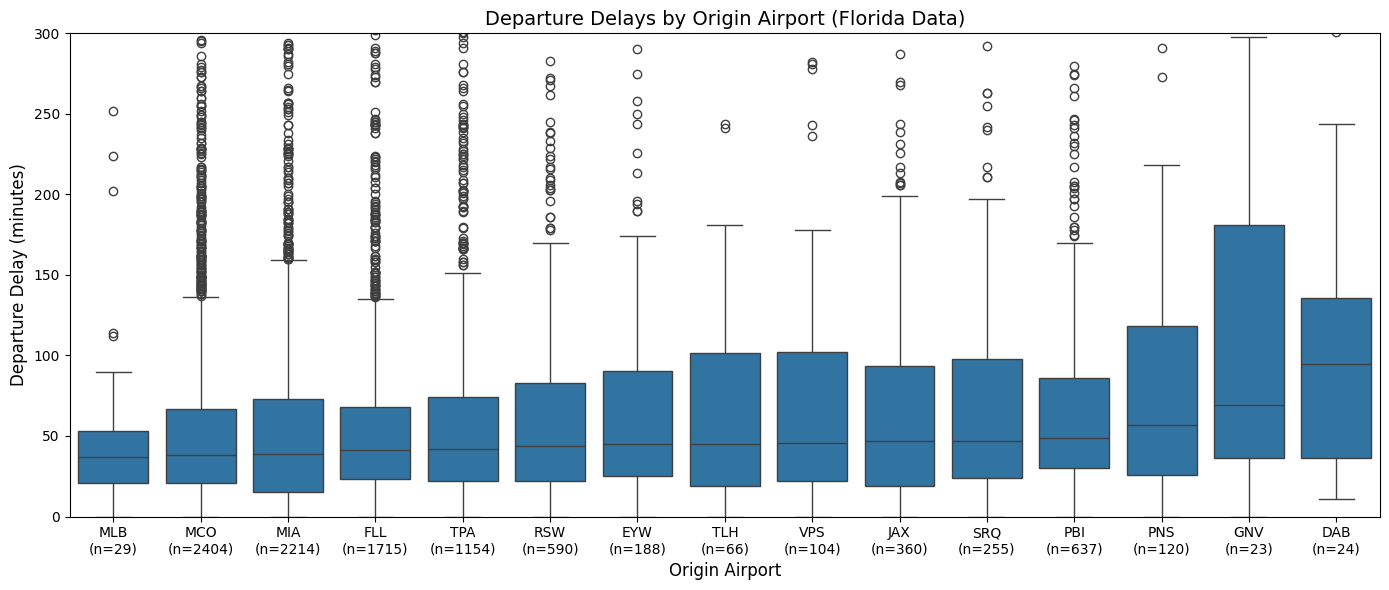

In [7]:

df = pd.read_csv("florida_delays_weather_data.csv", low_memory=False)

# Keep just what we need and drop missing values
data = df[["ORIGIN", "DEP_DELAY_NEW"]].dropna()

# Order airports by median departure delay (lowest -> highest)
order = (
    data.groupby("ORIGIN")["DEP_DELAY_NEW"]
        .median()
        .sort_values()
        .index
)

#  show counts under each airport label
counts = data["ORIGIN"].value_counts()
xtick_labels = [f"{a}\n(n={counts.get(a,0)})" for a in order]

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(x="ORIGIN", y="DEP_DELAY_NEW", data=data, order=order)

# Zoom the y-axis so the main distribution isn’t crushed by extreme outliers
plt.ylim(0, 300)

plt.title("Departure Delays by Origin Airport (Florida Data)", fontsize=14)
plt.ylabel("Departure Delay (minutes)", fontsize=12)
plt.xlabel("Origin Airport", fontsize=12)
plt.xticks(ticks=range(len(order)), labels=xtick_labels, rotation=0, ha="center")  # labels with counts

plt.tight_layout()
plt.show()

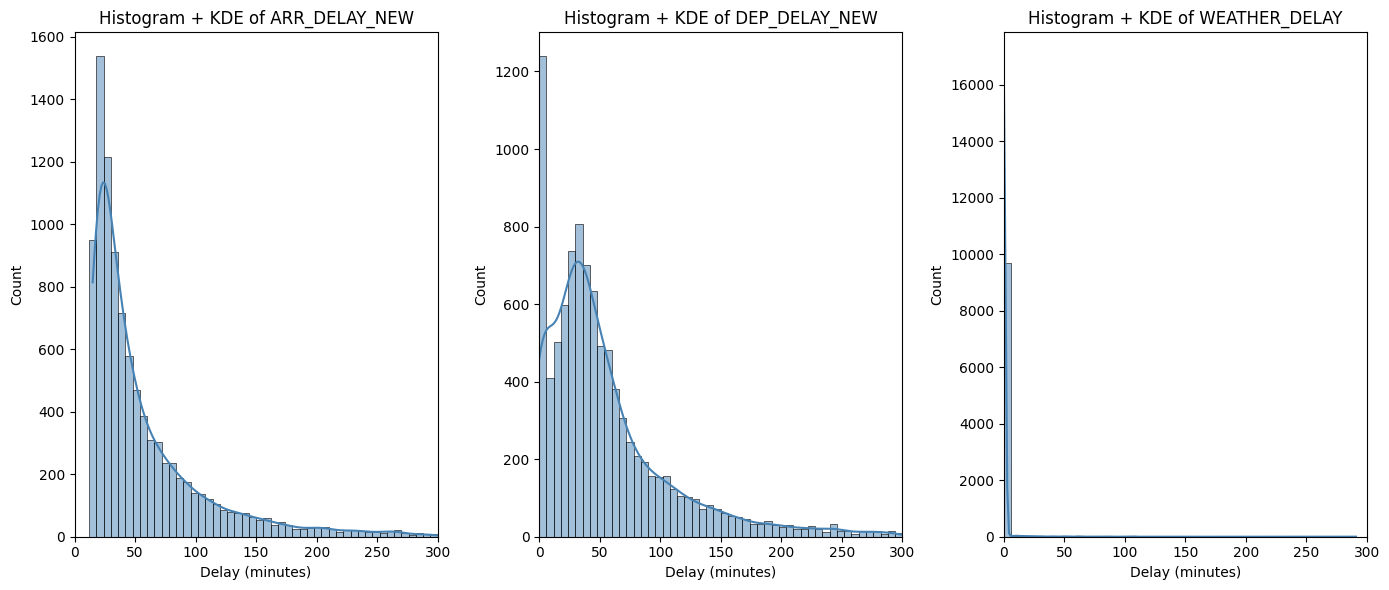

In [10]:
import numpy as np

df = pd.read_csv("florida_delays_weather_data.csv", low_memory=False)

# Delay variables to plot
delay_vars = ["ARR_DELAY_NEW", "DEP_DELAY_NEW", "WEATHER_DELAY"]
delay_vars = [c for c in delay_vars if c in df.columns]

# Plot config
BINS = 50
XRANGE = (0, 300)   # same zoom as before
LABEL_EVERY = 5     # label every Nth bar to avoid clutter (set to 1 to label all)

plt.figure(figsize=(14, 6))

for i, col in enumerate(delay_vars, 1):
    ax = plt.subplot(1, len(delay_vars), i)
    data = df[col].dropna()

    # Keep the plot comparable to before by zooming; counts computed on same range
    data_clipped = data[(data >= XRANGE[0]) & (data <= XRANGE[1])]

    # Draw histogram with KDE
    sns.histplot(data_clipped, bins=BINS, binrange=XRANGE,
                 kde=True, stat="count", color="steelblue", ax=ax)

    # Compute bin counts explicitly so labels match the visible bars
    counts, edges = np.histogram(data_clipped, bins=BINS, range=XRANGE)
    bin_centers = (edges[:-1] + edges[1:]) / 2



    ax.set_title(f"Histogram + KDE of {col}")
    ax.set_xlabel("Delay (minutes)")
    ax.set_ylabel("Count")
    ax.set_xlim(*XRANGE)

plt.tight_layout()
plt.show()

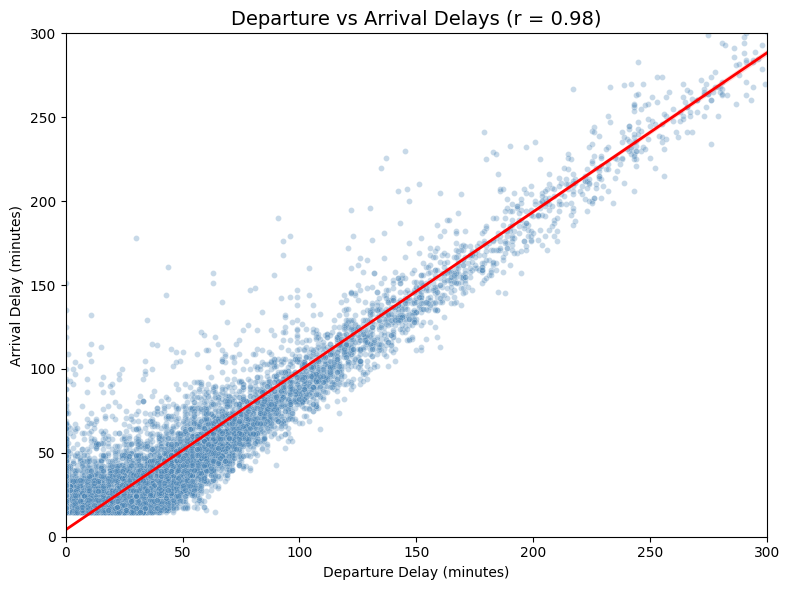

In [15]:
import math

df = pd.read_csv("florida_delays_weather_data.csv", low_memory=False)

X = "DEP_DELAY_NEW"
Y = "ARR_DELAY_NEW"

# Coerce to numeric just in case
for col in [X, Y]:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing rows
data = df[[X, Y]].dropna()

# Compute Pearson correlation for the title
r = data[X].corr(data[Y])

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x=X, y=Y, alpha=0.3, s=18, color="steelblue")
sns.regplot(data=data, x=X, y=Y, scatter=False, color="red", line_kws={"linewidth":2})

plt.title(f"Departure vs Arrival Delays (r = {r:.2f})", fontsize=14)
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.xlim(0, 300)   # focus on 0–300 minutes
plt.ylim(0, 300)
plt.tight_layout()
plt.show()